# Assignment 1: False Alarms

Author: Fredrik Boglind

## Introduction

Alarm fatigue is a critical problem in intensive care units (ICUs), where clinical staff are exposed to frequent monitor alarms, many of which are false positives. Here we use the **VTaC dataset** (Ventricular Tachycardia annotated alarms from ICUs) to build a classifier that predicts whether a ventricular tachycardia (VT) alarm is **True** or **False**.


### Physiological signals

The dataset we are working with contains **alarm events**, each such event contains a subset of the following signal types (Lehman et al., 2023):

**ECG (Electrocardiogram)**: Electrical activity of the heart, recorded from skin electrodes. Different *leads* (I, II, III, V, aVR, etc.) capture different viewing angles of the heart. VT appears as a rapid rhythm with broadened QRS complexes, but noise and artifacts can mimic this pattern, which is a key reason for false alarms (Lehman et al., 2023).

**PLETH (Plethysmogram / PPG)**: A photoplethysmography signal from a pulse oximeter, typically on the finger. It optically measures blood volume changes with each heartbeat, providing a pulsatile waveform that reflects peripheral perfusion.

**ABP (Arterial Blood Pressure)**: Beat-by-beat pressure measured via an arterial catheter. Not all ICU patients have arterial lines, making ABP the most commonly absent signal. When present, ABP is valuable because it can independently confirm or refute a cardiac event.  ABP waveforms can reduce false alarm rates for critical arrhythmias Aboukhalil et al. (2008).
_____________________________________________________________________________

**Dataset:**  
Lehman et al., *VTaC: A Benchmark Dataset of Ventricular Tachycardia Alarms from ICU Monitors*, NeurIPS 2023 Datasets and Benchmarks Track.  
Dataset available at [PhysioNet](https://physionet.org/content/vtac/1.0/) (DOI: 10.13026/z4f3-1f07).  
GitHub: [github.com/ML-Health/VTaC](https://github.com/ML-Health/VTaC).
Paper: [Lehman et al., 2023](https://proceedings.neurips.cc/paper_files/paper/2023/file/7a53bf4e02022aad32a4019d41b3b476-Paper-Datasets_and_Benchmarks.pdf).




### Imports

In [ ]:
import pandas as pd
import numpy as np
import wfdb
import os
from pathlib import Path
#from scipy.signal import butter, filtfilt, iirnotch

import sklearn as sk
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, classification_report
from sklearn.feature_selection import RFE
from scipy.signal import butter, filtfilt, iirnotch

import seaborn as sns
import matplotlib.pyplot as plt

from utility_functions import (
    classify_signal, load_event, load_all_events,
    filter_all, normalize_per_sample, extract_features,
)

import warnings
warnings.filterwarnings('ignore')



## Data Loading

### Dataset structure

The dataset is organised as follows:

- **`event_labels.csv`**: One row per alarm event. The `record` column identifies the patient recording, the `event` column identifies the specific alarm, and the `decision` column contains the expert-annotated label (True = real VT, False = false alarm).
- **`benchmark_data_split.csv`**: Assigns each event to a `train`, `val`, or `test` split. 

- **`waveforms/`**: A directory containing the actual physiological recordings in WFDB format. Sub-directories are named by patient record, and each contains up to five alarm event files.

We start by loading and merging the two CSV files into a unified dataframe with event identity, its split assignment, and its label.

In [2]:
DATA_DIR = Path('raw_data/vtac-a-benchmark-dataset-of-ventricular-tachycardia-alarms-from-icu-monitors-1.0/')
WAVEFORM_DIR = DATA_DIR / 'waveforms'
# Load the metadata files
labels_df = pd.read_csv(DATA_DIR / 'event_labels.csv')
splits_df = pd.read_csv(DATA_DIR / 'benchmark_data_split.csv')

# Merge to get one row per event with its split + label
df = splits_df.merge(labels_df, on=['record', 'event'], how='inner')

# Shape of original dfs
print(f"Labels:  {labels_df.shape}")
print(f"Splits:  {splits_df.shape}")
# Shape of merged df
print(f"Merged:  {df.shape}")
print(f"\nColumns after merge:\n{df.columns.tolist()}")
df.head()

Labels:  (5037, 3)
Splits:  (5037, 3)
Merged:  (5037, 4)

Columns after merge:
['split', 'record', 'event', 'decision']


,split,record,event,decision
0,train,003c13,003c13_0115,False
1,train,003c13,003c13_0126,False
2,train,004bad,004bad_0015,False
3,train,004bad,004bad_1115,False
4,train,004bad,004bad_1426,False


## Task 1: Predict whether or not an alarm is True or False

Before exploring the data, we note what the [VTaC data description](https://physionet.org/content/vtac/1.0/) (Lehman et al., 2023) tells us up front:

- **5,037 annotated VT alarm events** (28.61% true alarms), each labelled by at least two independent expert annotators
- Each event is a **6-minute waveform segment**: 5 minutes before the alarm onset and 1 minute after, all resampled to **250 Hz** (= 90,000 samples)
- Each recording contains **ECG leads** and **one or more pulsatile waveforms** (PLETH and/or ABP)
- Data comes from **3 major US hospitals** and **3 monitor manufacturers**
- Waveform files are stored in **WFDB format**, organised in sub-folders by patient record, with up to five alarm events selected per patient
- Pre-defined **train/val/test split** is provided in `benchmark_data_split.csv`

This gives us the high-level picture. What it does *not* tell us is the exact signal availability across events, which ECG lead combinations appear, how the splits are stratified, the distribution of events per patient, or whether there are quality issues like NaN values in the signals. That is what our exploration will focus on.

### Data Exploration

We explore the dataset in two stages: first the **metadata** (labels, splits, class balance), then the **waveform recordings** themselves. What want to understand the data before moving on to preprocessing and modelling.

#### 1.1 Class balance

In [3]:
print(f"Total alarm events: {len(df)}")
print(f"Unique patient records: {df['record'].nunique()}")

print(f"\nLabel distribution")
print(df['decision'].value_counts())
true_pct = df['decision'].mean() * 100
print(f"\nClass balance: {true_pct:.1f}% True alarms, {100-true_pct:.1f}% False alarms")

Total alarm events: 5037
Unique patient records: 2260

Label distribution
decision
False    3596
True     1441
Name: count, dtype: int64

Class balance: 28.6% True alarms, 71.4% False alarms


Of the 5,037 events in the dataset, 28.6% are true VT alarms and 71.4% are false alarms. We can see that most alarms are false positives. We will need to account for this imbalance.

#### 1.2 Split distribution

In [4]:
ct = pd.crosstab(df['split'], df['decision'], margins=True)
print(ct)

print("\nClass proportions per split:")
for split in ['train', 'val', 'test']:
    subset = df[df['split'] == split]
    print(f"  {split}: {subset['decision'].mean():.1%} True  (n={len(subset)})")

decision  False  True   All
split                      
test        345   137   482
train      2897  1163  4060
val         354   141   495
All        3596  1441  5037

Class proportions per split:
  train: 28.6% True  (n=4060)
  val: 28.5% True  (n=495)
  test: 28.4% True  (n=482)


We can see that the benchmark split has been stratified: all of the subsets have about the same class proportions (~28% True). 

The training set has 4060 events while the vla and train sets has ~500 events each.

#### 1.3 Events per patient

count    2260.000000
mean        2.228761
std         1.606308
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        21.000000
Name: event, dtype: float64


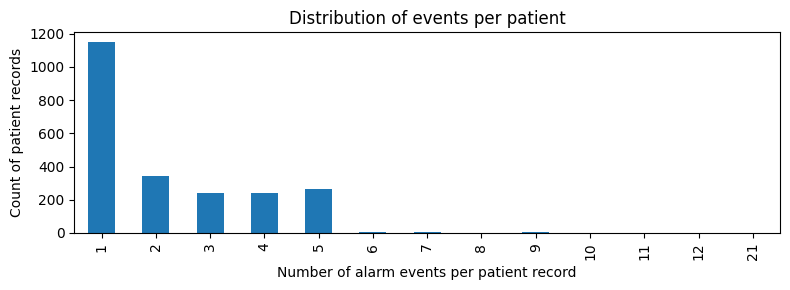

In [5]:
events_per_record = df.groupby('record')['event'].count()
print(events_per_record.describe())

fig, ax = plt.subplots(figsize=(8, 3))
events_per_record.value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_xlabel('Number of alarm events per patient record')
ax.set_ylabel('Count of patient records')
ax.set_title('Distribution of events per patient')
plt.tight_layout()
plt.show()

Patients have between 1 and 21 events (most between 1 and 5). The distribution is right-skewed: the median is 1 and 75% of patients have 3 or fewer events. This means a small number of patients account for a disproportionate share of alarms, and events from the same patient are likely correlated.

#### 1.4 Exploring the waveform files

The waveform data is stored in [WFDB format](https://physionet.org/content/wfdb/), where each event produces a pair of files: a `.dat` binary file and a `.hea` header file describing the recording. 

We start by looking at the folder structure for one patient, then open a single event to see what's inside.

##### Folder structure

In [6]:
# Pick the first patient record folder and list the contents
example_record = sorted(os.listdir(WAVEFORM_DIR))[0]
record_path = os.path.join(WAVEFORM_DIR, example_record)

print(f"Patient folder: {example_record}")
print(f"Contents:")
for f in sorted(os.listdir(record_path)):
    print(f"  {f}")


Patient folder: 003c13
Contents:
  003c13_0115.dat
  003c13_0115.hea
  003c13_0126.dat
  003c13_0126.hea


Each patient folder contains pairs of `.dat` and `.hea` files — one pair per alarm event. The `.hea` file is a small text header describing the recording (signal names, sampling rate, length, etc.), while the `.dat` file contains the actual signal data.

##### Reading a single event

We take a look at a single event

In the [WFDB documentation](https://www.physionet.org/physiotools/wag/header-5.htm) we can find an explanation of the headers.

The following attributes seem particulary interesting*:
- `n_sig`: Number of Signals (not necessarily equal to the number of signal files, since two or more signals can share a signal file)
- `sig_name`: Name of the signal, a list of channel names 
- `fs`: Sampling Frequency
- `sig_len`: Signal Length
- `units`: Units

*In the [VTaC GitHub repo](https://github.com/ML-Health/VTaC) we can see which attributes were used

In [7]:
example_event = df.iloc[0]['event'] # We pick the first event
example_path = str(WAVEFORM_DIR / example_record / example_event)
# Read just the header first to get metadata about the signals
header = wfdb.rdheader(example_path)

print(f"Event: {example_event}")
print(f"Number of signals: {header.n_sig}")
print(f"Signal names:      {header.sig_name}")
print(f"Sampling frequency: {header.fs} Hz")
print(f"Signal length:     {header.sig_len} samples")
print(f"Duration:          {header.sig_len / header.fs:.1f} seconds ({header.sig_len / header.fs / 60:.1f} minutes)")
print(f"Units:             {header.units}")

Event: 003c13_0115
Number of signals: 4
Signal names:      ['II', 'aVR', 'V', 'PLETH']
Sampling frequency: 250 Hz
Signal length:     90000 samples
Duration:          360.0 seconds (6.0 minutes)
Units:             ['mV', 'mV', 'mV', 'NU']


We alreadt new this from the data description, but now we have confirmed that an event is: a 6-minute recording (90,000 samples at 250 Hz), signal names tell us which channels are available in the particular event. Next we load the actual signal values and look at the numbers.

In [8]:
# Load the full record (header + signal data)
record = wfdb.rdrecord(example_path)

# The signal data is in record.p_signal, a 2D numpy array: (samples, channels)
print(f"Signal data shape: {record.p_signal.shape}")
print(f"  → {record.p_signal.shape[0]} time steps × {record.p_signal.shape[1]} channels")
print(f"\nSignal names: {record.sig_name}")
print(f"\nBasic statistics per channel:")
for i, name in enumerate(record.sig_name):
    col = record.p_signal[:, i]
    n_nan = np.isnan(col).sum()
    print(f"  {name:8s}  min={np.nanmin(col):10.3f}  max={np.nanmax(col):10.3f}  "
          f"mean={np.nanmean(col):10.3f}  NaNs={n_nan}")

Signal data shape: (90000, 4)
  → 90000 time steps × 4 channels

Signal names: ['II', 'aVR', 'V', 'PLETH']

Basic statistics per channel:
  II        min=    -0.760  max=     3.080  mean=    -0.004  NaNs=0
  aVR       min=    -1.530  max=     0.935  mean=    -0.004  NaNs=0
  V         min=    -1.110  max=     0.455  mean=    -0.004  NaNs=0
  PLETH     min=     0.000  max=     1.000  mean=     0.496  NaNs=0


The signal values are in the original physical units (e.g., millivolts for ECG, mmHg for ABP). The ranges differ between channel types. ECG values are small (sub-millivolt) while ABP values are in the tens to hundreds. We will need to do normalization later.

##### Plotting a single event

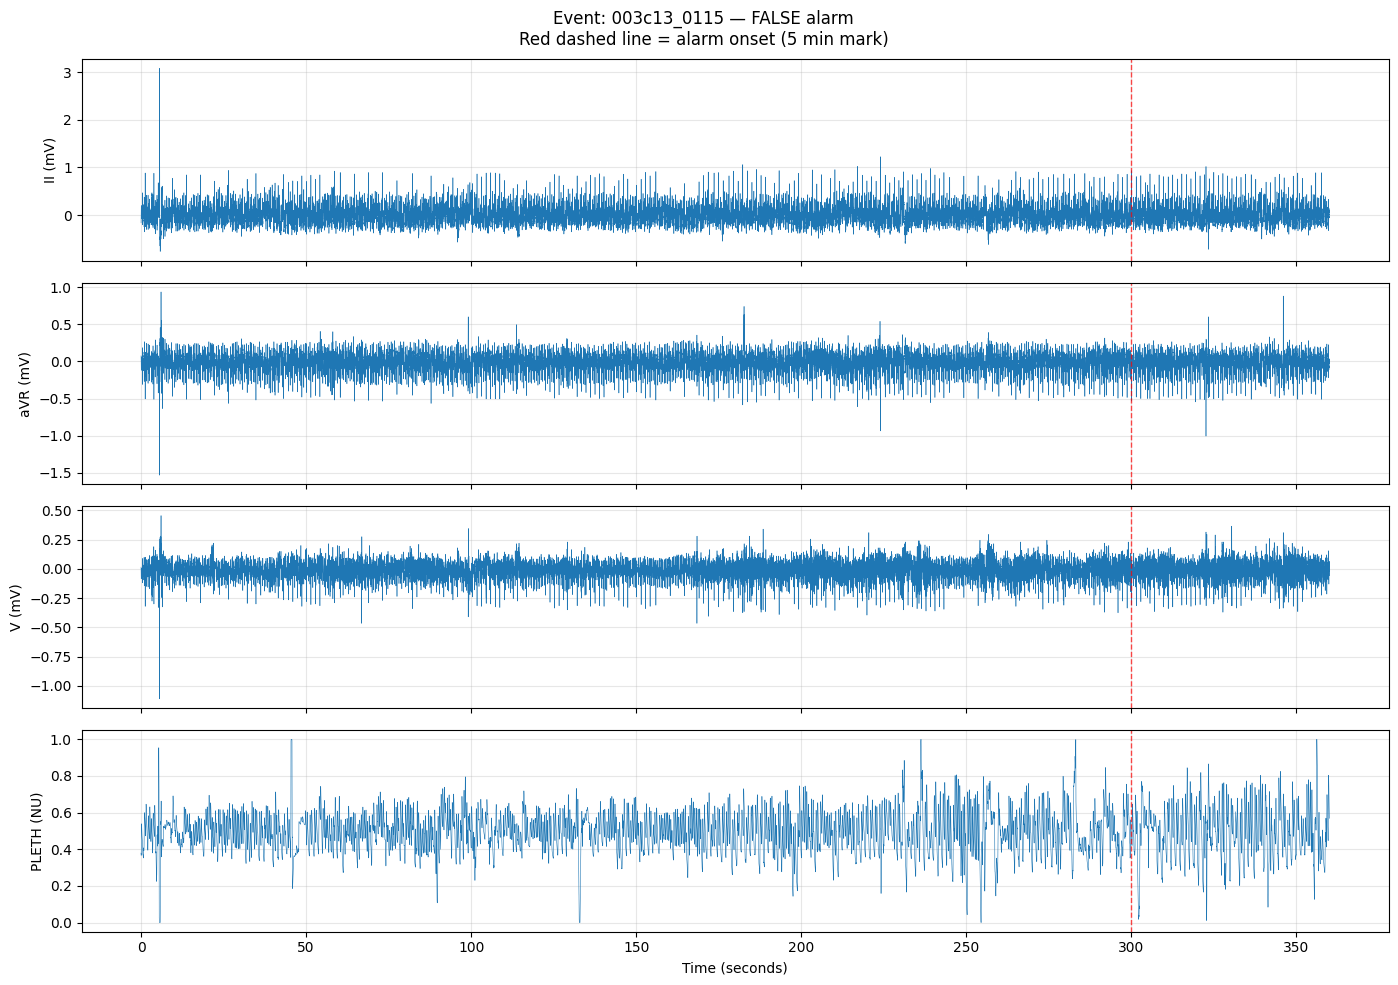

In [9]:
# Plot all channels for the one event
fig, axes = plt.subplots(len(record.sig_name), 1, figsize=(14, 2.5 * len(record.sig_name)), sharex=True)
if len(record.sig_name) == 1:
    axes = [axes]

t = np.arange(record.sig_len) / record.fs  # time axis in seconds

for i, (ax, name) in enumerate(zip(axes, record.sig_name)):
    ax.plot(t, record.p_signal[:, i], linewidth=0.4)
    ax.set_ylabel(f"{name} ({record.units[i]})")
    ax.grid(True, alpha=0.3)
    # Mark the alarm onset at t=300s (5 minutes)
    ax.axvline(x=300, color='red', linestyle='--', linewidth=1, alpha=0.7)

axes[-1].set_xlabel('Time (seconds)')
label = df.iloc[0]['decision']
fig.suptitle(f"Event: {example_event} — {'TRUE alarm' if label else 'FALSE alarm'}\n"
             f"Red dashed line = alarm onset (5 min mark)", fontsize=12)
plt.tight_layout()
plt.show()

The red dashed line marks the alarm onset at the 5-minute mark. Everything to the left is the lead-up to the alarm, the final minute is what followed.

##### Comparing a True vs False alarm

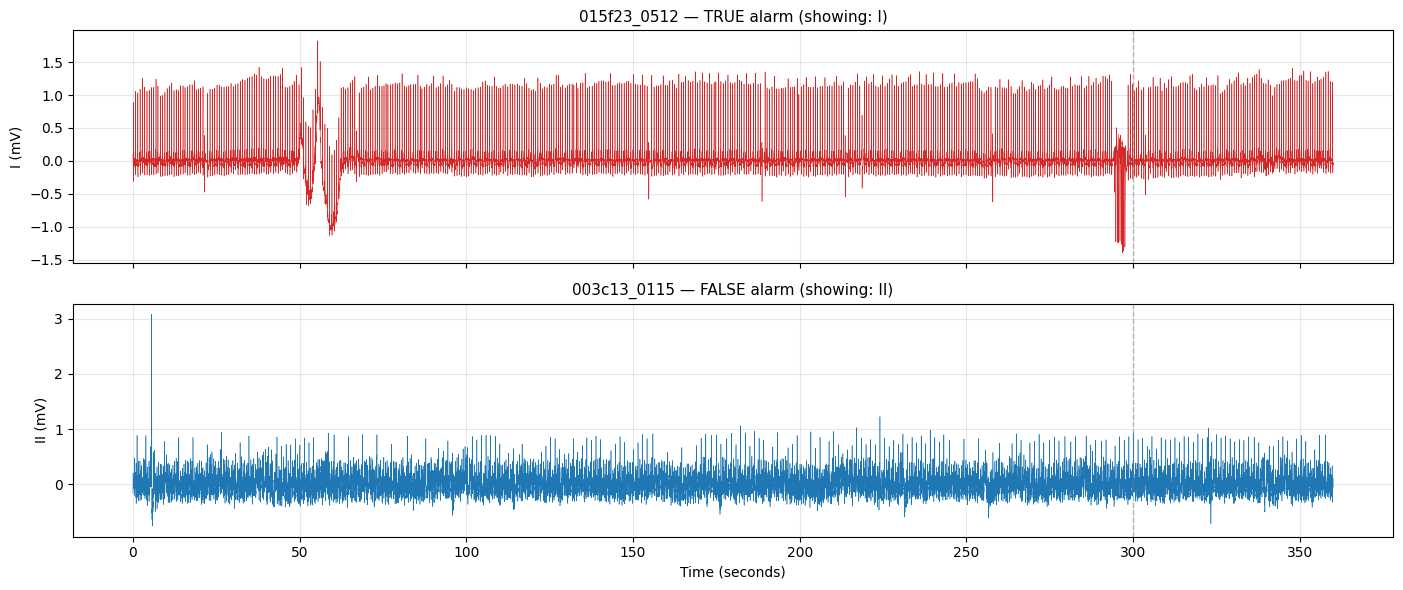

In [10]:
# Pick one True and one False alarm
true_row = df[df['decision'] == True].iloc[0]
false_row = df[df['decision'] == False].iloc[0]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

for ax, row, color in zip(axes, [true_row, false_row], ['tab:red', 'tab:blue']):
    rec = wfdb.rdrecord(str(WAVEFORM_DIR / row['record'] / row['event']))
    t = np.arange(rec.sig_len) / rec.fs
    # Plot the first ECG lead
    ax.plot(t, rec.p_signal[:, 0], linewidth=0.4, color=color)
    ax.axvline(x=300, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    label_str = 'TRUE alarm' if row['decision'] else 'FALSE alarm'
    ax.set_title(f"{row['event']} — {label_str} (showing: {rec.sig_name[0]})", fontsize=11)
    ax.set_ylabel(f"{rec.sig_name[0]} ({rec.units[0]})")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()

Visually, we should see a difference: True VT alarms show rapid arrythmia, while false alarms may show, noise, or normal rhythms that were misclassified by the monitor (Lehman et al). 

In these particular samples a difference seem to be discenrible: The **False** alarm appears to be noisy, while the **True** alarm show that someting is happening at 50s and ~300s. 

However, these are just to random samples and it is also worth noting that these two events to have different first ECG leads (I vs II), we should therefore be careful when comparing them.

#### 1.5 Signal availability across the full dataset

So far we've looked at individual events. Now we look at all of the data: which signal types are present for all of the 5000+ events? Not every patient has every type of sensor attached, some events may lack ABP or PLETH recordings. 

We read just the header of each event file and catalogue what we find (this is fast, since we don't need to load the signal data).

In [11]:
# Scan all event headers to catalogue signal availability
signal_info = []

for _, row in df.iterrows():
    path = str(WAVEFORM_DIR / row['record'] / row['event'])
    try:
        hdr = wfdb.rdheader(path)
        sig_upper = [s.upper() for s in hdr.sig_name]
        signal_info.append({
            'event': row['event'],
            'record': row['record'],
            'n_signals': hdr.n_sig,
            'sig_names': hdr.sig_name,
            'sig_len': hdr.sig_len,
            'has_pleth': 'PLETH' in sig_upper,
            'has_abp': 'ABP' in sig_upper,
            'n_ecg': sum(1 for s in sig_upper if s not in ('PLETH', 'ABP')),
        })
    except Exception as e:
        signal_info.append({
            'event': row['event'], 'record': row['record'],
            'n_signals': 0, 'sig_names': [], 'sig_len': 0,
            'has_pleth': False, 'has_abp': False, 'n_ecg': 0,
        })
        print(f"  WARNING: Could not read {row['event']}: {e}")

sig_df = pd.DataFrame(signal_info)
print(f"Scanned {len(sig_df)} event headers.")

Scanned 5037 event headers.


In [12]:
# Summarise signal availability
print("Signal availability")
print(f"  Events with PLETH: {sig_df['has_pleth'].sum()}/{len(sig_df)} ({sig_df['has_pleth'].mean():.1%})")
print(f"  Events with ABP:   {sig_df['has_abp'].sum()}/{len(sig_df)} ({sig_df['has_abp'].mean():.1%})")

print(f"\nNumber of ECG leads per event")
print(sig_df['n_ecg'].value_counts().sort_index().to_string())

print(f"\nTotal signals per event")
print(sig_df['n_signals'].value_counts().sort_index().to_string())

Signal availability
  Events with PLETH: 4681/5037 (92.9%)
  Events with ABP:   1837/5037 (36.5%)

Number of ECG leads per event
n_ecg
1       44
2        7
3     3237
4     1612
5        4
7       59
8        3
12      71

Total signals per event
n_signals
1        1
2       31
3       51
4     2354
5     1945
6      520
7        2
8        2
9       57
10       3
14      71


In [13]:
# Find the event(s) with only 1 signal
one_sig = sig_df[sig_df['n_signals'] == 1]
print(f"Events with 1 signal: {len(one_sig)}")
for _, row in one_sig.iterrows():
    rec = wfdb.rdrecord(str(WAVEFORM_DIR / row['record'] / row['event']))
    print(f"\n  Event:   {row['event']}")
    print(f"  Signals: {rec.sig_name}")
    print(f"  Units:   {rec.units}")
    print(f"  Length:  {rec.sig_len} samples ({rec.sig_len/250:.0f}s)")
    print(f"  Stats:   min={rec.p_signal[:,0].min():.3f}  max={rec.p_signal[:,0].max():.3f}")
    print(f"  NaNs:    {np.isnan(rec.p_signal).sum()}")
    label = df[df['event'] == row['event']]['decision'].values[0]
    print(f"  Label:   {label}")

Events with 1 signal: 1

  Event:   569ea7_0074
  Signals: ['II']
  Units:   ['mV']
  Length:  90000 samples (360s)
  Stats:   min=-3.145  max=6.185
  NaNs:    0
  Label:   False


One event stood out since it contained only a single ECG, still, it seems to be a valid recording and so we keep it in the dataset. Three of its four channels will be filled with zeroes.

Next we look at what combination of signal names occur in the data.

In [14]:
# What are the specific signal name combinations?
sig_df['combinations'] = sig_df['sig_names'].apply(lambda names: ' + '.join(sorted([s.upper() for s in names])))
print("Signal combinations (top 10)")
print(sig_df['combinations'].value_counts().head(10).to_string())

Signal combinations (top 10)
combinations
AVR + II + PLETH + V                                                          1878
ABP + AVR + II + PLETH + V                                                     933
I + II + III + PLETH + V                                                       706
ABP + I + II + III + PLETH + V                                                 495
I + II + III + V                                                               254
II + III + PLETH + V                                                            82
ABP + AVF + AVL + AVR + I + II + III + PLETH + V1 + V2 + V3 + V4 + V5 + V6      71
ABP + I + II + PLETH + V                                                        68
I + II + PLETH + V                                                              63
ABP + AVF + AVL + AVR + I + II + III + PLETH + V1                               56


The most common recording setup includes 2-3 ECG leads plus PLETH (with or without ABP). Some events have as many as 12 ECG leads from full 12-lead recordings. For our 4-channel pipeline, we select the first two ECG leads from each event, this means we discard additional leads in signal-rich events (a simplification that follows the approach in the VTaC GitHub code). We note that ABP is absent in ~2/3 of all events.

**Findings:**
- ECG lead count varies widely: most events have 3-4 ECG leads, but one event has only 1 and 71 events have the full 12. The most common combinations include leads II, V, and aVR.
- PLETH is available in 92.9% of events. ABP is available in only 36.5%, making it the primary source of missing data.
- One event (569ea7_0074) contains only a single ECG lead.
- For our preprocessing pipeline, we will standardise to a fixed 4-channel layout: two ECG leads, PLETH, and ABP. This follows the approach used in the VTaC benchmark code (Lehman et al., 2023). This means we will discard additional ECG leads when events have many signals.

#### 1.6 Missing data and signal quality

Before deciding how to handle missing signals, we should check whether the fact that a value is missing in itself is related to the alarm label. If ABP were present mostly in true alarms, for instance, the model could learn to use signal availability as a shortcut instead of learning from the actual waveforms.

In [15]:
# Check missingness in relation to label
sig_merged = sig_df.merge(df[['event', 'decision']], on='event')

print("ABP availability by label")
print(pd.crosstab(sig_merged['decision'], sig_merged['has_abp'], margins=True))

print("\nPLETH availability by label")
print(pd.crosstab(sig_merged['decision'], sig_merged['has_pleth'], margins=True))

# We sample a few events and check for NaN values
nan_counts = []
sample_idxs = np.random.RandomState(42).choice(len(df), size=min(200, len(df)), replace=False)

for idx in sample_idxs:
    row = df.iloc[idx]
    try:
        rec = wfdb.rdrecord(str(WAVEFORM_DIR / row['record'] / row['event']))
        n_nan = np.isnan(rec.p_signal).sum()
        nan_counts.append({'event': row['event'], 'n_nan': n_nan, 'total': rec.p_signal.size})
    except:
        pass

nan_df = pd.DataFrame(nan_counts)
n_with_nans = (nan_df['n_nan'] > 0).sum()
print(f"\nSampled {len(nan_df)} events for NaN check:")
print(f"Events with NaN values: {n_with_nans}/{len(nan_df)}")
if n_with_nans > 0:
    print(f"Max NaN count in a single event: {nan_df['n_nan'].max()}")
else:
    print("No NaN values found in the sampled events.")

ABP availability by label
has_abp   False  True   All
decision                   
False      2332  1264  3596
True        868   573  1441
All        3200  1837  5037

PLETH availability by label
has_pleth  False  True   All
decision                    
False        191  3405  3596
True         165  1276  1441
All          356  4681  5037

Sampled 200 events for NaN check:
Events with NaN values: 25/200
Max NaN count in a single event: 95480


The presence of ABP and PLETH is roughly proportional across both classes (~35% and ~97% respectively), so missingness does not appear to predict the label and imputation won't introduce bias.

So far we have looked at which channels are present or absent in each event, for example, whether a patient has an ABP signal at all. But we need to check for a second type of missingness: a channel that exists in the file may still contain NaNs. We need to remove these, since before filtering.

In [16]:
# Look at NaNs at channel level for a sample of events
nan_details = []
sample_idxs = np.random.RandomState(42).choice(len(df), size=min(200, len(df)), replace=False)

for idx in sample_idxs:
    row = df.iloc[idx]
    try:
        rec = wfdb.rdrecord(str(WAVEFORM_DIR / row['record'] / row['event']))
        per_channel = [np.isnan(rec.p_signal[:, ch]).sum() for ch in range(rec.n_sig)]
        if any(n > 0 for n in per_channel):
            nan_details.append({
                'event': row['event'],
                'sig_names': rec.sig_name,
                'nans_per_channel': dict(zip(rec.sig_name, per_channel)),
                'total_samples': rec.sig_len,
            })
    except:
        pass

print(f"Events with NaNs: {len(nan_details)}/200")
for d in nan_details[:5]:  # show first 5
    print(f"\n  {d['event']}:")
    for name, count in d['nans_per_channel'].items():
        if count > 0:
            pct = count / d['total_samples'] * 100
            print(f"    {name}: {count}/{d['total_samples']} NaN ({pct:.0f}%)")

Events with NaNs: 25/200

  b2e9a2_0042:
    ABP: 354/90000 NaN (0%)

  d82835_0039:
    II: 64/90000 NaN (0%)
    aVR: 64/90000 NaN (0%)
    V: 64/90000 NaN (0%)

  022a37_0057:
    ABP: 16960/90000 NaN (19%)

  e1e841_0040:
    II: 448/90000 NaN (0%)
    aVR: 448/90000 NaN (0%)
    MCL: 14584/90000 NaN (16%)
    V: 75912/90000 NaN (84%)

  364137_0201:
    PLETH: 1/90000 NaN (0%)


About 12.5% of sampled events have NaN values in one or more channels. We replace NaNs with zero (`np.nan_to_num`) before filtering, so brief glitches get smoothed out and heavily affected channels behave like absent ones.

### Data Cleaning & Preprocessing

Based on our exploration, we now define a preprocessing pipeline. The key decisions are:

1. **Channel alignment** — Standardise all events to a fixed 4-channel layout: [ECG1, ECG2, PLETH, ABP]. Missing channels are zero-filled, and we track which channels are present.
2. **Signal filtering** — Remove noise using channel-specific filters (adapted from the [VTaC repository](https://github.com/ML-Health/VTaC)).
3. **Normalisation** — Z-score standardisation per sample.

Each step is documented and motivated below.

#### Step 1: Load waveforms into a consistent format

Different events have different numbers and names of signals. To process them uniformly, we map each signal to one of four standard slots based on its name. ECG signals (whatever their lead name) go into slots 0 and 1; PLETH goes into slot 2; ABP into slot 3. If a signal type is absent, that slot stays filled with zeros.

This zero-filling approach is a deliberate choice — it preserves all events in the dataset rather than discarding any. We track availability separately so that we can (a) avoid filtering/normalising empty channels, and (b) later compare models trained with vs. without imputation, as required by the assignment.

In [17]:
SAMPLING_FREQ = 250
CHANNEL_NAMES = ['ECG1', 'ECG2', 'PLETH', 'ABP']

# Signal names that indicate ECG leads (the dataset uses various lead names)
ECG_LEAD_NAMES = {'II', 'I', 'III', 'V', 'AVR', 'AVL', 'AVF', 'MCL', 'ECG'}
PLETH_NAMES = {'PLETH'}
ABP_NAMES = {'ABP'}

# Quick test of the loading function
test_row = df.iloc[0]
wf, avail = load_event(test_row['event'], test_row['record'], WAVEFORM_DIR,
                        ECG_LEAD_NAMES, PLETH_NAMES, ABP_NAMES)
print(f"Shape: {wf.shape}")
print(f"Available: { {CHANNEL_NAMES[i]: avail[i] for i in range(4)} }")

Shape: (4, 90000)
Available: {'ECG1': True, 'ECG2': True, 'PLETH': True, 'ABP': False}


#### Step 2: Load all events

In [18]:
print("Loading all waveforms (this may take a minute or two)...")
waveforms, labels, availability, event_ids = load_all_events(df=df, data_dir=WAVEFORM_DIR,ecg_leads=ECG_LEAD_NAMES, pleth_names=PLETH_NAMES, abp_names=ABP_NAMES)
print(f"Done. Loaded {waveforms.shape[0]} events, shape: {waveforms.shape}")

Loading all waveforms (this may take a minute or two)...
Done. Loaded 5037 events, shape: (5037, 4, 90000)


In [19]:
# Document what we have
print("Channel availability in loaded data")
for i, name in enumerate(CHANNEL_NAMES):
    present = availability[:, i].sum()
    missing = len(waveforms) - present
    print(f"  {name:6s}: {present} present, {missing} missing ({missing/len(waveforms):.1%})")

n_complete = (availability.sum(axis=1) == 4).sum()
print(f"\nEvents with all 4 channels: {n_complete}/{len(waveforms)} ({n_complete/len(waveforms):.1%})")
print(f"Events with missing channels: {len(waveforms) - n_complete}")
print(f"\n No events were deleted. Missing channels are zero-filled and tracked via the availability mask.")

Channel availability in loaded data
  ECG1  : 5037 present, 0 missing (0.0%)
  ECG2  : 4993 present, 44 missing (0.9%)
  PLETH : 4681 present, 356 missing (7.1%)
  ABP   : 1837 present, 3200 missing (63.5%)

Events with all 4 channels: 1761/5037 (35.0%)
Events with missing channels: 3276

 No events were deleted. Missing channels are zero-filled and tracked via the availability mask.


Only 35% of events have all four channels available. The missing data is dominated by ABP (absent in 63.5% of events), with smaller amounts of missing PLETH (7.1%) and ECG2 (0.9%). ECG1 is always present. No events were deleted. The impact of this missing data will be evaluated after feature extraction, where we compare imputation strategies against the zero-fill baseline (assignment requirement 5).

#### Step 3: Signal filtering

Next we remove noise by applying channel-specific filters. Here we follow VTaC [GitHub repo](https://github.com/ML-Health/VTaC) (Lehman et al., 2023):

**ECG (leads 1 & 2):**
- 1 Hz highpass — removes slow baseline drift caused by breathing or electrode movement
- 30 Hz lowpass — removes high-frequency noise above the clinically relevant ECG range
- 60 Hz notch — removes power line interference (US standard)

**PLETH (PPG):**
- 60 Hz notch — removes power line interference
- 0.5–5 Hz bandpass — isolates the pulse waveform, removing both slow drift and high-freq noise

**ABP (arterial blood pressure):**
- 60 Hz notch — removes power line interference
- 16 Hz lowpass — smooths high-frequency artifacts while preserving the blood pressure waveform

All filters use low order (order 2) Butterworth design to minimise ringing. We only filter channels that are actually present — zero-filled missing channels are left untouched.

Filter code adapted from [filtering.py](https://github.com/ML-Health/VTaC) (Lehman et al., 2023).

In [20]:
print("Applying signal filters (this could take a minute or two)...")
waveforms_filtered = filter_all(waveforms, availability) #See utility_functions.py for details
print("Filtering complete.")

Applying signal filters (this takes about a minute and a half)...
Filtering complete.


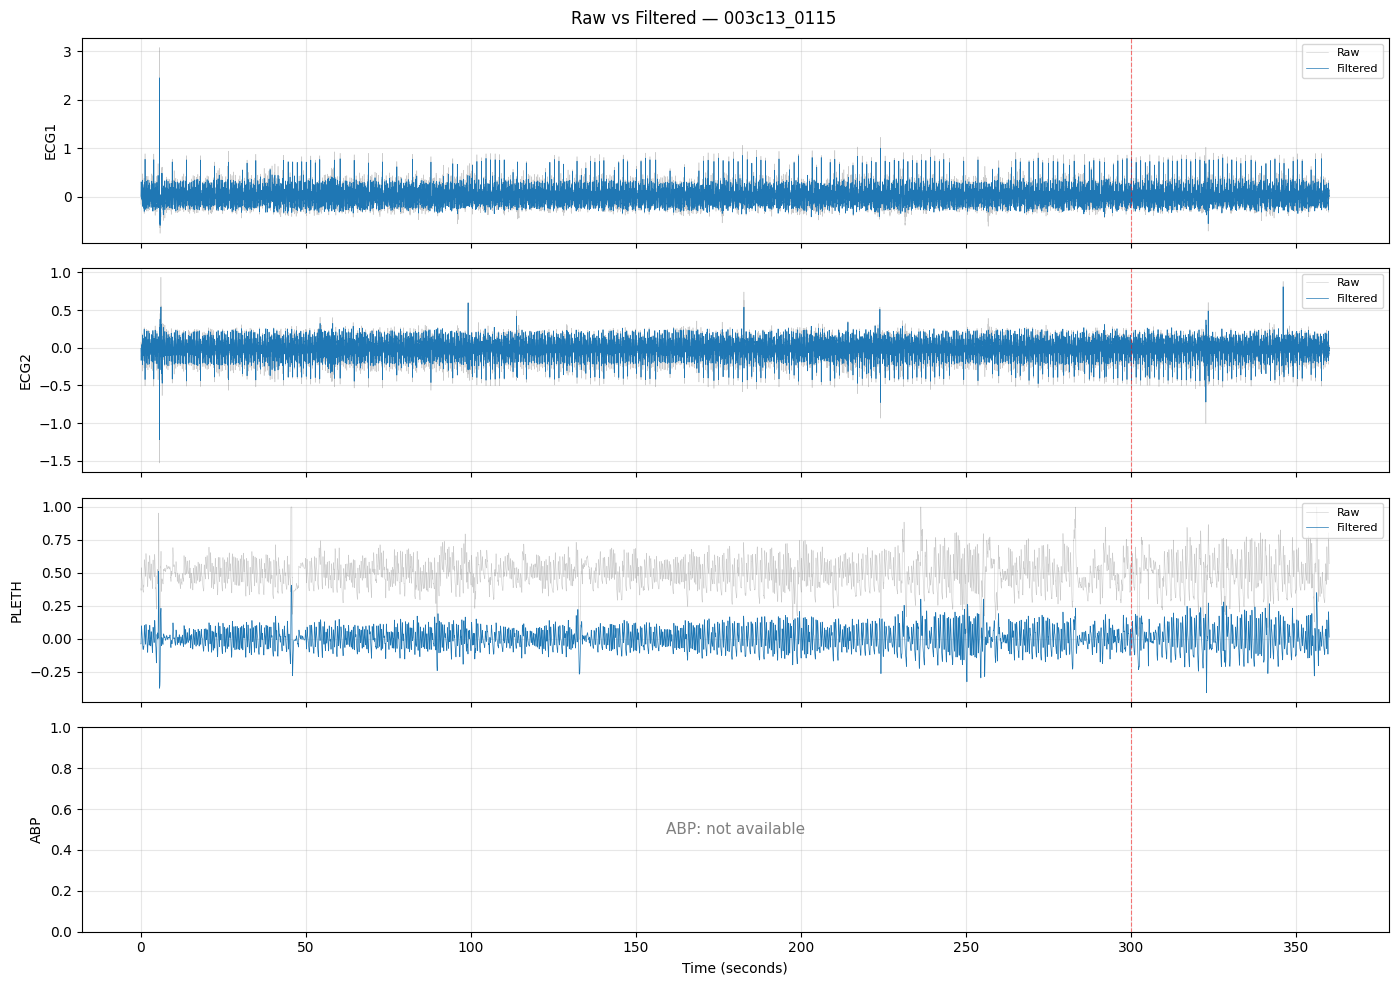

In [21]:
# Visualise the effect of filtering on one event
example_idx = 0
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
t = np.arange(waveforms.shape[2]) / SAMPLING_FREQ

for ch, (ax, name) in enumerate(zip(axes, CHANNEL_NAMES)):
    if availability[example_idx, ch]:
        ax.plot(t, waveforms[example_idx, ch], alpha=0.4, linewidth=0.4, label='Raw', color='gray')
        ax.plot(t, waveforms_filtered[example_idx, ch], linewidth=0.5, label='Filtered')
        ax.legend(loc='upper right', fontsize=8)
    else:
        ax.text(0.5, 0.5, f'{name}: not available', transform=ax.transAxes,
                ha='center', va='center', fontsize=11, color='gray')
    ax.set_ylabel(name)
    ax.axvline(x=300, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)')
fig.suptitle(f'Raw vs Filtered — {event_ids[example_idx]}', fontsize=12)
plt.tight_layout()
plt.show()

Filtering reduces high-frequency noise in the ECG leads and isolates the pulse waveform in PLETH. The ABP channel is not present for this event.

#### Step 4: Normalisation

We apply **per-sample z-score normalisation**: each channel of each event is standardised using its own mean and standard deviation. This is preferred over population-level normalisation because:

- Signal amplitudes vary between patients (different body compositions, electrode placements)
- Different hospitals and monitor manufacturers produce different absolute values
- Per-sample normalisation makes each event self-contained

Only channels that are actually present are normalised. Zero-filled missing channels remain at zero.

*Normalisation approach from [VTaC preprocessing/standardize.py](https://github.com/ML-Health/VTaC).*

In [22]:
print("Normalizing...")
waveforms_normalized = normalize_per_sample(waveforms_filtered, availability) #See utility_functions.py for details
print("Done.")
print(f"Final waveform shape: {waveforms_normalized.shape}")

Normalizing...
Done.
Final waveform shape: (5037, 4, 90000)


#### Preprocessing summary

In [23]:
# Reconstruct split assignments for the loaded events
event_to_split = df.set_index('event')['split'].to_dict()
split_labels = np.array([event_to_split[e] for e in event_ids])

print("Data after preprocessing")
for split_name in ['train', 'val', 'test']:
    mask = split_labels == split_name
    n = mask.sum()
    n_true = labels[mask].sum()
    print(f"  {split_name:5s}: {n} events  ({n_true} True, {n - n_true} False, {n_true/n:.1%} True)")

print(f"\nPipeline:")
print(f"  1. Loaded {len(waveforms)} events into 4-channel arrays (zero-fill missing signals)")
print(f"  2. Applied signal-specific filtering (ECG: HP+LP+notch, PLETH: bandpass, ABP: LP+notch)")
print(f"  3. Per-sample z-score normalisation")
print(f"  Output shape: {waveforms_normalized.shape} — (events, channels, time samples)")
print(f"\nNo rows deleted. Missing channels tracked via availability mask ({(~availability).any(axis=1).sum()} events have one or more missing channels).")

Data after preprocessing
  train: 4060 events  (1163 True, 2897 False, 28.6% True)
  val  : 495 events  (141 True, 354 False, 28.5% True)
  test : 482 events  (137 True, 345 False, 28.4% True)

Pipeline:
  1. Loaded 5037 events into 4-channel arrays (zero-fill missing signals)
  2. Applied signal-specific filtering (ECG: HP+LP+notch, PLETH: bandpass, ABP: LP+notch)
  3. Per-sample z-score normalisation
  Output shape: (5037, 4, 90000) — (events, channels, time samples)

No rows deleted. Missing channels tracked via availability mask (3276 events have one or more missing channels).


All 5037 events were loaded into a 4 by 90,000 array with zero-filling for missing channels and nan_to_num for in-signal NaN values. Signal-specific filters were applied only to present channels. Per-sample z-score normalisation standardised each channel independently. No events were deleted. The class balance was preserved for all splits. 3,276 events (65%) have at least one missing channel (most of which are ABP).

### Feature Extraction

Next we extract statistical features from the preprocessed waveforms for model training. For each of the four channels in each event, we compute five summary statistics: mean, standard deviation, minimum, maximum, skewness, kurtosis, and range. This produces a feature vector of 20 values per event (7 features × 4 channels).

Missing channels produce NaN values in their derived features, which will be handled by imputation in the next step.

In [29]:
print("Extracting features...")
feat_df = extract_features(waveforms_normalized, availability, channel_names=CHANNEL_NAMES)  # See utility_functions.py for details
feat_df['split'] = [event_to_split[e] for e in event_ids]
feat_df['decision'] = labels # 
print(f"Feature matrix shape: {feat_df.shape}")
print(f"Features per event: {feat_df.shape[1] - 2}")  # minus label and split

print(f"\nNaN counts by channel:")
for ch in ['ECG1', 'ECG2', 'PLETH', 'ABP']:
    ch_cols = [c for c in feat_df.columns if c.startswith(ch)]
    n_missing = feat_df[ch_cols[0]].isna().sum()
    print(f"  {ch:>5s}: {n_missing} missing")


Extracting features...
Feature matrix shape: (5037, 22)
Features per event: 20

NaN counts by channel:
   ECG1: 0 missing
   ECG2: 44 missing
  PLETH: 356 missing
    ABP: 3200 missing


We extract five statistical features per channel (mean, standard deviation, min, max, range), giving 20 features per event. The NaN counts show what we we found earlier: ECG1 is present in all events, ABP is absent in about two-thirds. These missing values will be handled by imputation in the next step.

### Step 5: Imputation

We compare five strategies for handling missing values (following the methods in Lab 2). The imputers are fit on the training set only and then applied to validation and test sets, to prevent data leakage

In [31]:
# Separate features, labels, and splits
feature_cols = [c for c in feat_df.columns if c not in ['decision', 'split']]
X = feat_df[feature_cols]
y = feat_df['decision'].astype(int)
splits = feat_df['split']

# Split into train/val/test
X_train = X[splits == 'train'].copy()
X_val = X[splits == 'val'].copy()
X_test = X[splits == 'test'].copy()
y_train = y[splits == 'train']
y_val = y[splits == 'val']
y_test = y[splits == 'test']

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"NaN values in train: {X_train.isnull().sum().sum()}")

Train: (4060, 20), Val: (495, 20), Test: (482, 20)
NaN values in train: 14590


Our chosen imputation methods are Zero-fill (following Lehman), Mean imputation, Median imputation and Iterative imputation

In [32]:
# Define imputation strategies
imp_methods = {}

# 1. Zero fill (as in VTaC repo)
imp_methods['zero_fill'] = SimpleImputer(strategy='constant', fill_value=0)

# 2. Mean imputation
imp_methods['mean'] = SimpleImputer(strategy='mean')

# 3. Median imputation
imp_methods['median'] = SimpleImputer(strategy='median')

# 4. Iterative imputation
imp_methods['iterative'] = IterativeImputer(random_state=42, max_iter=10)

# Apply each strategy: fit on train, transform train/val/test
imputed_datasets = {}

In [33]:
for name, imputer in imp_methods.items():
    X_tr = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index)
    X_v = pd.DataFrame(imputer.transform(X_val), columns=feature_cols, index=X_val.index)
    X_te = pd.DataFrame(imputer.transform(X_test), columns=feature_cols, index=X_test.index)
    imputed_datasets[name] = (X_tr, X_v, X_te)
    print(f"\n{name}: NaNs remaining — train: {X_tr.isnull().sum().sum()}, val: {X_v.isnull().sum().sum()}")

# Drop rows with missing values
X_train_drop = X_train.dropna()
y_train_drop = y_train.loc[X_train_drop.index]
X_val_drop = X_val.dropna()
y_val_drop = y_val.loc[X_val_drop.index]
X_test_drop = X_test.dropna()
y_test_drop = y_test.loc[X_test_drop.index]

print(f"\ndrop_rows: Train {X_train.shape[0]} → {X_train_drop.shape[0]}, "
      f"Val {X_val.shape[0]} → {X_val_drop.shape[0]}, "
      f"Test {X_test.shape[0]} → {X_test_drop.shape[0]}")


zero_fill: NaNs remaining — train: 0, val: 0

mean: NaNs remaining — train: 0, val: 0

median: NaNs remaining — train: 0, val: 0

iterative: NaNs remaining — train: 0, val: 0

drop_rows: Train 4060 → 1402, Val 495 → 177, Test 482 → 182


### Step 6: Modelling

We evaluate two models:
- **Logistic Regression**: a linear model that serves as a simple, interpretable baseline. It directly outputs class probabilities, and its coefficients can be inspected to understand which features drive predictions. It also supports class_weight='balanced' to handle the class imbalance.


- **Random Forest**: a non-linear ensemble method that can capture interactions between features (e.g., the combination of high ECG variability and low ABP variability) that a linear model would miss. It is robust to feature scaling and provides built-in feature importance estimates.

In [34]:
# Define models. We set class_weight='balanced' because of the 71/29 imbalance
models = {
    'logistic_regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'random_forest': RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42),
}

# We evaluate all the combinations of imputation strategy × model
results = []

for imp_name, (X_tr, X_v, X_te) in imputed_datasets.items():
    for model_name, model in models.items():
        clf = model.__class__(**model.get_params())  # fresh copy
        clf.fit(X_tr, y_train)
        y_pred = clf.predict(X_te)
        
        results.append({
            'imputation': imp_name,
            'model': model_name,
            'accuracy': accuracy_score(y_test, y_pred),
            'f1': f1_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
        })

# Evaluate drop_rows separately (different y sets)
for model_name, model in models.items():
    clf = model.__class__(**model.get_params())
    clf.fit(X_train_drop, y_train_drop)
    y_pred = clf.predict(X_test_drop)
    
    results.append({
        'imputation': 'drop_rows',
        'model': model_name,
        'accuracy': accuracy_score(y_test_drop, y_pred),
        'f1': f1_score(y_test_drop, y_pred),
        'precision': precision_score(y_test_drop, y_pred),
        'recall': recall_score(y_test_drop, y_pred),
    })

results_df = pd.DataFrame(results)
print(results_df.sort_values('f1', ascending=False).to_string(index=False))

imputation               model  accuracy       f1  precision   recall
    median logistic_regression  0.630705 0.587963   0.430508 0.927007
      mean logistic_regression  0.624481 0.585812   0.426667 0.934307
 iterative logistic_regression  0.624481 0.585812   0.426667 0.934307
 zero_fill logistic_regression  0.628631 0.580796   0.427586 0.905109
 drop_rows logistic_regression  0.615385 0.567901   0.414414 0.901961
      mean       random_forest  0.765560 0.519149   0.622449 0.445255
    median       random_forest  0.765560 0.519149   0.622449 0.445255
 zero_fill       random_forest  0.761411 0.502165   0.617021 0.423358
 iterative       random_forest  0.753112 0.497890   0.590000 0.430657
 drop_rows       random_forest  0.741758 0.433735   0.562500 0.352941


The differences between imputation strategies are small within each model, suggesting that the choice of imputation is not critical for these features. Logistic regression achieves higher F1 scores (~0.58–0.59) than random forest (~0.50–0.52), though with very high recall (~93%) at the cost of low precision (~43%), it labels most events as true alarms. Random forest is more conservative, with higher precision (~0.62) but much lower recall (~0.45). Dropping incomplete rows performs worst in both cases, likely because it discards the roughly two-thirds of events that lack ABP.

### Step 7: Feature Importance

For best model we Median imputaion with Logistic Regression. This model produced the best F1 score (0.587).

Recursive Feature Elimination ranking
(1 = last to be eliminated = most important)
    feature  ranking
    ABP_std        1
  PLETH_std        2
  PLETH_min        3
PLETH_range        4
  PLETH_max        5
   ECG2_std        6
    ABP_min        7
  ABP_range        8
    ABP_max        9
   ECG2_max       10
   ECG2_min       11
 ECG2_range       12
   ECG1_std       13
   ECG1_max       14
 ECG1_range       15
   ECG1_min       16
   ABP_mean       17
 PLETH_mean       18
  ECG2_mean       19
  ECG1_mean       20


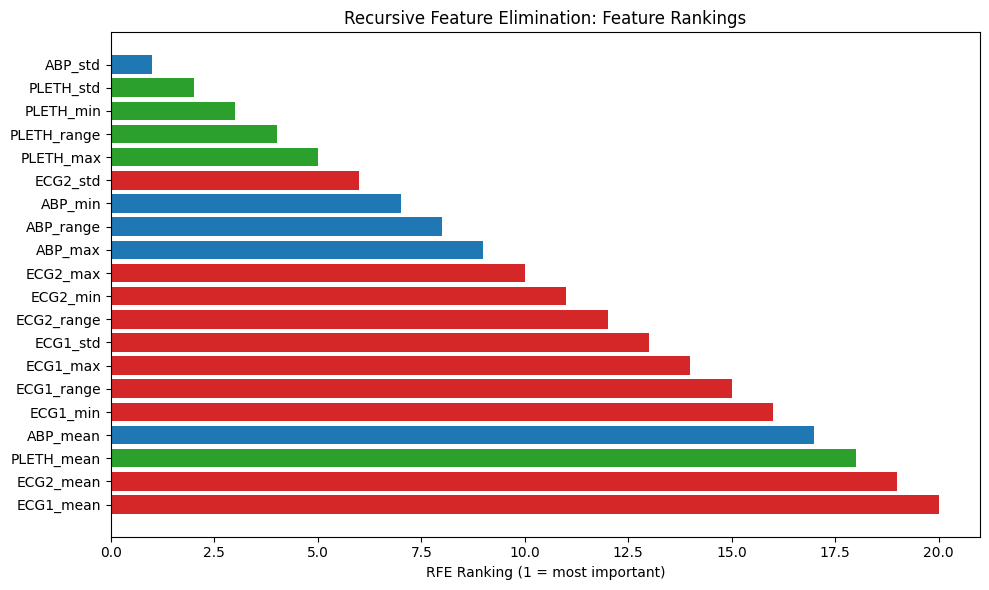

In [36]:
# Use median imputation + logistic regression (best F1: 0.587)
X_tr, X_v, X_te = imputed_datasets['median']

# Fit the model
clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf.fit(X_tr, y_train)

# Recursive Feature Elimination
rfe = RFE(estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
          n_features_to_select=1, step=1)
rfe.fit(X_tr, y_train)

rfe_df = pd.DataFrame({
    'feature': feature_cols,
    'ranking': rfe.ranking_
}).sort_values('ranking')

print("Recursive Feature Elimination ranking")
print("(1 = last to be eliminated = most important)")
print(rfe_df.to_string(index=False))

# Visualise RFE ranking. Color represents signal type (ECG, PLETH, ABP).
fig, ax = plt.subplots(figsize=(10, 6))
rfe_sorted = rfe_df.sort_values('ranking')
colors = ['tab:red' if 'ECG' in f else 'tab:green' if 'PLETH' in f else 'tab:blue' for f in rfe_sorted['feature']]
ax.barh(rfe_sorted['feature'], rfe_sorted['ranking'], color=colors)
ax.set_xlabel('RFE Ranking (1 = most important)')
ax.set_title('Recursive Feature Elimination: Feature Rankings')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Standard deviation is the most important feature type, with ABP_std ranking first and PLETH_std second. PLETH features overall rank highly (four of the top five positions), possibly, pulse waveform characteristics are informative for distinguishing true from false alarms. Mean features rank last for all channels, which is expected since per-sample z-score normalisation centers each signal around zero.

## Results and Discussion

Our **best model** is logistic regression with median imputation, achieving an F1 score of 0.588 on the validation set. Accuracy is 0.631, but this is misleading given the class imbalance (71% of alarms are false). The model achieves high recall (0.927) — it catches most true alarms — but low precision (0.431), meaning it also labels many false alarms as true.

Random forest achieves higher accuracy (0.766) and precision (0.622) but lower recall (0.445) and F1 (0.519). It misses more than half of true alarms, which is arguably worse in a clinical setting where missing a real VT event could be dangerous.

The **choice of imputation strategy** had little effect on performance within either model. This is likely because our features are simple global statistics, and the imputed values for absent channels carry limited information regardless of method.

**Feature importance analysis** via RFE showed that standard deviation is the most informative feature type across all channels, with ABP_std ranked first. This is consistent with the nature of VT: a sudden change in heart rhythm should increase signal variability. Mean features ranked last, which is expected since per-sample z-score normalisation centers each signal around zero.

### Limitations

The features used here, five summary statistics per channel are simple. They discard all temporal structure: the ordering of samples, the shape of individual heartbeats, and the timing of the alarm onset are all lost. The baseline Lehman et al. (2023)
uses time-frequency features and perform substantially better than our models.

ABP is absent in roughly two-thirds of events, yet ABP_std was ranked as the most important feature. This means the model's strongest signal is not available for most patients, which limits performance.